# LLM

Reference: https://python.langchain.com/docs/get_started/quickstart.html

The core building block of LangChain applications is the LLMChain. This combines three things:

LLM: The language model is the core reasoning engine here. In order to work with LangChain, you need to understand the different types of language models and how to work with them.
Prompt Templates: This provides instructions to the language model. This controls what the language model outputs, so understanding how to construct prompts and different prompting strategies is crucial.
Output Parsers: These translate the raw response from the LLM to a more workable format, making it easy to use the output downstream.

There are two types of language models, which in LangChain are called:

1. LLMs: this is a language model which takes a string as input and returns a string
2. ChatModels: this is a language model which takes a list of messages as input and returns a message
The input/output for LLMs is simple and easy to understand - a string. But what about ChatModels? The input there is a list of ChatMessages, and the output is a single ChatMessage. A ChatMessage has two required components:

* **content:** This is the content of the message.
* **role**: This is the role of the entity from which the ChatMessage is coming from.


LangChain provides several objects to easily distinguish between different roles:

* HumanMessage: A ChatMessage coming from a human/user.
* AIMessage: A ChatMessage coming from an AI/assistant.
* SystemMessage: A ChatMessage coming from the system.
* FunctionMessage: A ChatMessage coming from a function call.
If none of those roles sound right, there is also a ChatMessage class where you can specify the role manually. For more information on how to use these different messages most effectively, see our prompting guide.

LangChain exposes a standard interface for both, but it's useful to understand this difference in order to construct prompts for a given language model. The standard interface that LangChain exposes has two methods:

* predict: Takes in a string, returns a string
* predict_messages: Takes in a list of messages, returns a message.
Let's see how to work with these different types of models and these different types of inputs. First, let's import an LLM and a ChatModel.

In [1]:
%pip install langchain

     ---------------------------------------- 1.6/1.6 MB 9.3 MB/s eta 0:00:00
  Using cached PyYAML-6.0.1-cp311-cp311-win_amd64.whl (144 kB)
  Using cached SQLAlchemy-2.0.20-cp311-cp311-win_amd64.whl (2.0 MB)
     ------------------------------------- 320.6/320.6 kB 10.0 MB/s eta 0:00:00
     ---------------------------------------- 94.4/94.4 kB ? eta 0:00:00
  Using cached numpy-1.25.2-cp311-cp311-win_amd64.whl (15.5 MB)
  Using cached pydantic-2.3.0-py3-none-any.whl (374 kB)
  Using cached requests-2.31.0-py3-none-any.whl (62 kB)
  Using cached attrs-23.1.0-py3-none-any.whl (61 kB)
  Using cached charset_normalizer-3.2.0-cp311-cp311-win_amd64.whl (96 kB)
  Using cached multidict-6.0.4-cp311-cp311-win_amd64.whl (28 kB)
  Using cached yarl-1.9.2-cp311-cp311-win_amd64.whl (60 kB)
     ---------------------------------------- 44.9/44.9 kB 2.3 MB/s eta 0:00:00
  Using cached aiosignal-1.3.1-py3-none-any.whl (7.6 kB)
     ---------------------------------------- 49.4/49.4 kB 2.4 MB/s eta 0


[notice] A new release of pip available: 22.3.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install openai

Note: you may need to restart the kernel to use updated packages.Collecting openai
     ---------------------------------------- 76.5/76.5 kB 4.4 MB/s eta 0:00:00
  Using cached tqdm-4.66.1-py3-none-any.whl (78 kB)




[notice] A new release of pip available: 22.3.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install python_dotenv


[notice] A new release of pip available: 22.3.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached python_dotenv-1.0.0-py3-none-any.whl (19 kB)


#

# Langchain Benefits

LangChain is a framework for developing applications powered by language models, especially large language models (LLMs). It allows you to connect a language model to other sources of data, and to interact with its environment. LangChain provides modular components and use-case specific chains that make it easy to work with language models¹².

ChatGPT is a large language model (LLM) created by OpenAI that can comprehend and generate text that closely resembles human language. It is particularly good at engaging in coherent and lifelike conversations, providing informative responses to queries²³.

LangChain and ChatGPT are not mutually exclusive, but rather complementary. LangChain can be used with ChatGPT to enhance its capabilities and performance. For example, LangChain can help ChatGPT access external data sources, such as web pages, documents, or databases, and use them to provide more relevant and personalized answers. LangChain can also help ChatGPT maintain a consistent and coherent conversation history, and handle different types of user inputs, such as commands, questions, or feedback².

Therefore, LangChain is more beneficial than ChatGPT in the sense that it can augment ChatGPT's functionality and usability, and enable more complex and diverse applications powered by language models. LangChain is not a replacement for ChatGPT, but rather a framework that can leverage ChatGPT's strengths and overcome its limitations. I hope this helps. 😊

References:
1. Using LangChain with ChatGPT GPT-3.5: Step-by-Step Guide. https://pykit.org/using-langchain-with-chatgpt-gpt-3-5-step-by-step-guide/.
2. Chatbot Development with ChatGPT & LangChain: A Context ... - DataCamp. https://www.datacamp.com/tutorial/building-context-aware-chatbots-leveraging-langchain-framework-for-chatgpt.

In [1]:
# LLM - predict: Takes in a string, returns a string
from dotenv import load_dotenv, find_dotenv
import os

load_dotenv(find_dotenv())

True

In [12]:
# Fetch the OPENAI_API_KEY from the .env file
OPENAI_API_KEY=os.environ.get('OPENAI_API_KEY')

In [28]:
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI

In [32]:
chatgpt = ChatOpenAI(model_name='gpt-3.5-turbo')

In [33]:
chatgpt.predict("hii")

Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_ret

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [29]:
llm = OpenAI()
chat_model = ChatOpenAI()

In [30]:
llm.predict("hi!")

Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 10.0 seconds as it raised RateLimitError: You exceeded your current quota, please ch

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [ ]:
chat_model.predict("hi!")

In [26]:
# from langchain.llms import OpenAI
# llm = OpenAI(temperature=0.1, model_name="gpt-3.5-turbo-16k", openai_api_key=OPENAI_API_KEY)

c:\Users\burha\Mentorskool\Self Learning\GenAI\llm-venv\Lib\site-packages\langchain\llms\openai.py:200: UserWarning: You are trying to use a chat model. This way of initializing it is no longer supported. Instead, please use: `from langchain.chat_models import ChatOpenAI`
  warnings.warn(
c:\Users\burha\Mentorskool\Self Learning\GenAI\llm-venv\Lib\site-packages\langchain\llms\openai.py:787: UserWarning: You are trying to use a chat model. This way of initializing it is no longer supported. Instead, please use: `from langchain.chat_models import ChatOpenAI`
  warnings.warn(


In [27]:
# llm.predict("hii")

Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 10.0 seconds as it raised RateLimitError: You exceeded your current quota, please ch

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [13]:
# from langchain.llms import OpenAI # also explore the bedrock
# from langchain.chat_models import ChatOpenAI

In [22]:
# chat = ChatOpenAI(
#     model_name='gpt-3.5-turbo-16k',
#     temperature = 0.6,
#     openai_api_key = OPENAI_API_KEY,
# )

In [23]:
# from langchain.llms import OpenAIChat

# self.llm = OpenAIChat(
#     model_name='gpt-3.5-turbo-16k',
#     temperature = self.config.llm.temperature,
#     openai_api_key = self.config.llm.openai_api_key,         
#     max_tokens=self.config.llm.max_tokens                 
# )

In [ ]:
llm.predict("hi!")

In [20]:
llm = ChatOpenAI(temperature=0, request_timeout=120)

In [21]:
llm.predict("hi!")

Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_ret

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [ ]:
name = llm("I want to open a restaurant for Indian food. Suugest a fency name for this.")
name

In [18]:
chat_model.predict("hiii")

Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.chat_models.openai.ChatOpenAI.completion_with_retry.<locals>._completion_with_ret

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [34]:
davinci = OpenAI(model_name='text-davinci-003')

In [35]:
davinci.predict("hii")

Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 10.0 seconds as it raised RateLimitError: You exceeded your current quota, please ch

RateLimitError: You exceeded your current quota, please check your plan and billing details.

In [1]:
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI

In [2]:
llm = OpenAI()
chat_model = ChatOpenAI()

In [3]:
llm.predict("hii")

Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 8.0 seconds as it raised RateLimitError: You exceeded your current quota, please check your plan and billing details..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 10.0 seconds as it raised RateLimitError: You exceeded your current quota, please ch

RateLimitError: You exceeded your current quota, please check your plan and billing details.

# 

References:
1. https://www.youtube.com/watch?v=nAmC7SoVLd8&t=311s - In progress
2. https://www.pinecone.io/learn/series/langchain/langchain-intro/ - Not Started

In [3]:
from dotenv import load_dotenv, find_dotenv
import os

load_dotenv(find_dotenv()) # once OPENAI_API_KEY is loaded to the environment variable, OpenAI will automatically fetch it

True

In [8]:
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI

#### What is temperature parameter? - https://ai.plainenglish.io/mastering-the-gpt-3-temperature-parameter-with-ruby-af727cba3b5c

The temperature parameter is the setting in OpenAI that affects the randomness of the output. A lower temperature will result in more predictable output, while a higher temperature will result in more random output. The temperature parameter is set between 0 and 1, with 0 being the most predictable and 1 being the most random.

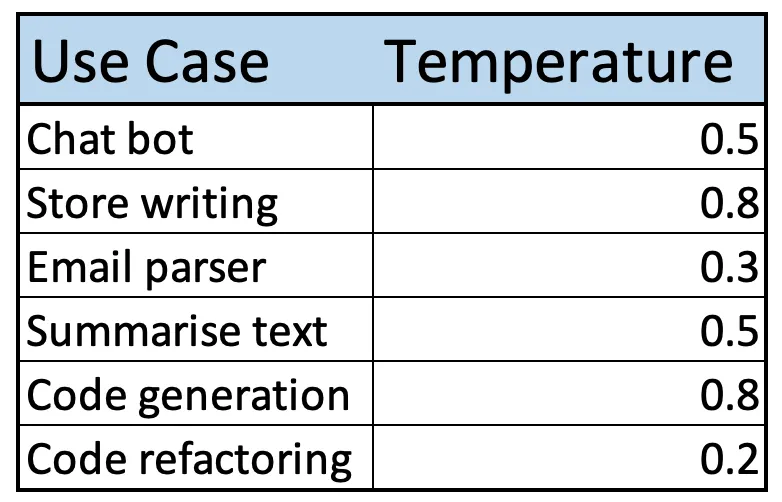

In [10]:
llm = OpenAI(temperature=0.6)
# chat_model = ChatOpenAI()

In [12]:
name = llm("I want to open a restaurant for Indian food. Suggest a fency name for this")
name

' restaurant\n\nSpice of India.'

#### Prompt Templates - https://python.langchain.com/docs/modules/model_io/prompts



In [14]:
from langchain.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template(
    "Tell me a {adjective} joke about {content}"
)
prompt_template.format(adjective="funny", content="chickens")

'Tell me a funny joke about chickens'

For additional validation, specify input_variables explicitly. These variables will be compared against the variables present in the template string during instantiation, raising an exception if there is a mismatch; for example,

In [19]:
# this code will throw validation error, as two variables are present in the template while in the input_variables
# parameter, we have passed only one

# invalid_prompt = PromptTemplate(
#     input_variables=["adjective"],
#     template="Tell me a {adjective} joke about {content}."
# )

In [20]:
valid_prompt = PromptTemplate(
    input_variables=["adjective", "content"],
    template="Tell me a {adjective} joke about {content}."
)

### LLMChain

In [23]:
## when we pass input as a list, the following error comes:
## ValueError: A single string input was passed in, but this chain expects multiple inputs ({'content', 'adjective'}).
#  When a chain expects multiple inputs, please call it by passing in a dictionary, eg `chain({'foo': 1, 'bar': 2})`

### LLMChain

A LLMChain is the most common type of chain. It consists of a PromptTemplate, a model (either an LLM or a ChatModel), and an optional output parser. This chain takes multiple input variables, uses the PromptTemplate to format them into a prompt. It then passes that to the model. Finally, it uses the OutputParser (if provided) to parse the output of the LLM into a final format.

In [25]:
# let's import LLMChain
from langchain.chains import LLMChain

chain = LLMChain(llm=llm, prompt=valid_prompt)
chain.run({"adjective": "funny", "content": "dogs"})

'\n\nQ: What do you call a dog that can do magic?\nA: A Labracadabrador!'

### SimpleSequentialChain

1. Single input
2. Single output
3. Different intermediary steps (output of one step will become the input of others).

In [ ]:
from langchain.chains import LLMChain

In [38]:
llm = OpenAI(temperature=0.6)

prompt_template_name = PromptTemplate(
    input_variables=["cuisine"],
    template="I want to open a restaurant for {cuisine} food. Suggest a fency name for it."
)

name_chain = LLMChain(llm=llm, prompt=prompt_template_name)

In [39]:
prompt_template_items = PromptTemplate(
    input_variables=["restaurant_name"],
    template="Suggest some menu items for {restaurant_name}. Return it as a comma separated list."
)

food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items)

In [40]:
from langchain.chains import SimpleSequentialChain

chain = SimpleSequentialChain(chains = [name_chain, food_items_chain], verbose=True)
response = chain.run("Indian")
response



> Entering new SimpleSequentialChain chain...


Tandoori Nites


Tandoori Chicken, Chicken Tikka, Seekh Kabab, Paneer Tikka, Naan, Butter Chicken, Dal Makhani, Chicken Biryani, Vegetable Biryani, Aloo Gobi, Raita.

> Finished chain.


'\n\nTandoori Chicken, Chicken Tikka, Seekh Kabab, Paneer Tikka, Naan, Butter Chicken, Dal Makhani, Chicken Biryani, Vegetable Biryani, Aloo Gobi, Raita.'

Explanation: 

1. The prompt entered by the user will be name of cuisine (Indian, Mexican, Italian, etc..)
2. Based on this, it will be formatted by PromptTemplate and passed to model via OpenAI.
3. The model will answer the question. (will suggest the name of the restaurant).
4. The output of this step will become the input of second step. (Where it is asked to suggest some menu items for of the {restaurant_name})
5. At the end we will get list of menu items as final output.

### Sequential Chain

1. Multiple Inputs
2. Multiple Outputs

In [30]:
from langchain.chains import LLMChain

In [48]:
llm = OpenAI(temperature=0.6)

prompt_template_name = PromptTemplate(
    input_variables=["cuisine"],
    template="I want to open a restaurant for {cuisine} food. Suggest a fency name for it."
)

name_chain = LLMChain(llm=llm, prompt=prompt_template_name, output_key="restaurant_name")

In [49]:
prompt_template_items = PromptTemplate(
    input_variables=["restaurant_name"],
    template="Suggest some menu items for {restaurant_name}. Return it as a comma separated list."
)

food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items, output_key="menu_items")

In [50]:
from langchain.chains import SequentialChain

chain = SequentialChain(
    chains=[name_chain, food_items_chain],
    input_variables=['cuisine'],
    output_variables=['restaurant_name', 'menu_items'],
    verbose=True
)

chain({'cuisine': 'Arabic'}) # have passed the dictionary as it takes multiple inputs, in this 
# we don't have to call any method, directly pass the input inside chain object.



> Entering new SequentialChain chain...

> Finished chain.


{'cuisine': 'Arabic',
 'restaurant_name': '\n\nThe Arabian Bistro',
 'menu_items': '\n\nKebab Platter, Hummus, Falafel, Lamb Tagine, Baked Kibbeh, Baba Ganoush, Couscous, Stuffed Grape Leaves, Spiced Lamb Pita, Tabbouleh, Baklava.'}

## Agents

In [2]:
from langchain.agents import AgentType, initialize_agent, load_tools
from langchain.llms import OpenAI

llm = OpenAI()

tools = load_tools(["wikipedia", "llm-math"], llm=llm)

agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, # Zero-shot means the agent functions on the current action only — it has no memory
    verbose=True
)

agent.run("When was Elon musk born? What is his age right now in 2023?")

ImportError: Could not import wikipedia python package. Please install it with `pip install wikipedia`.

In [3]:
%pip install wikipedia

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached beautifulsoup4-4.12.2-py3-none-any.whl (142 kB)
  Using cached soupsieve-2.4.1-py3-none-any.whl (36 kB)
  Running setup.py install for wikipedia: started
  Running setup.py install for wikipedia: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: wikipedia is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip available: 22.3.1 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from langchain.agents import AgentType, initialize_agent, load_tools
from langchain.llms import OpenAI

llm = OpenAI()

tools = load_tools(["wikipedia", "llm-math"], llm=llm)

agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, # Zero-shot means the agent functions on the current action only — it has no memory
    verbose=True
)

agent.run("When was Elon musk born? What is his age right now in 2023?")



> Entering new AgentExecutor chain...
 I need to find the date of his birth and then calculate his age.
Action: Wikipedia
Action Input: Elon Musk
Observation: Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a business magnate and investor. Musk is the founder, chairman, CEO and chief technology officer of SpaceX;  angel investor, CEO, product architect and former chairman of Tesla, Inc.; owner, chairman and CTO of X Corp.; founder of the Boring Company; co-founder of Neuralink and OpenAI; and president of the Musk Foundation. He is the wealthiest person in the world, with an estimated net worth of US$217 billion as of August 2023, according to the Bloomberg Billionaires Index, and $219 billion according to Forbes, primarily from his ownership stakes in both Tesla and SpaceX.Musk was born in Pretoria, South Africa, and briefly attended the University of Pretoria before immigrating to Canada at age 18, acquiring citizenship through his Canadian-born mother. Tw

Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: Rate limit reached for default-text-davinci-003 in organization org-bopjHrMEteRaVQsQwATYgdCP on requests per min. Limit: 3 / min. Please try again in 20s. Contact us through our help center at help.openai.com if you continue to have issues. Please add a payment method to your account to increase your rate limit. Visit https://platform.openai.com/account/billing to add a payment method..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: Rate limit reached for default-text-davinci-003 in organization org-bopjHrMEteRaVQsQwATYgdCP on requests per min. Limit: 3 / min. Please try again in 20s. Contact us through our help center at help.openai.com if you continue to have issues. Please add a payment method to your account to increase your rate limit. Visit https://platform.openai.com/acco

 I now know the final answer
Final Answer: Elon Musk was born on June 28, 1971 and is currently 52 years old in 2023.

> Finished chain.


'Elon Musk was born on June 28, 1971 and is currently 52 years old in 2023.'

```
> Entering new AgentExecutor chain...
 I need to find the date of his birth and then calculate his age.
Action: Wikipedia
Action Input: Elon Musk
Observation: Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a business magnate and investor. Musk is the founder, chairman, CEO and chief technology officer of SpaceX;  angel investor, CEO, product architect and former chairman of Tesla, Inc.; owner, chairman and CTO of X Corp.; founder of the Boring Company; co-founder of Neuralink and OpenAI; and president of the Musk Foundation. He is the wealthiest person in the world, with an estimated net worth of US$217 billion as of August 2023, according to the Bloomberg Billionaires Index, and $219 billion according to Forbes, primarily from his ownership stakes in both Tesla and SpaceX.Musk was born in Pretoria, South Africa, and briefly attended the University of Pretoria before immigrating to Canada at age 18, acquiring citizenship through his Canadian-born mother. Two years later, he matriculated at Queen's University in Kingston, Ontario. Musk later transferred to the University of Pennsylvania, and received bachelor's degrees in economics and physics there. He moved to California in 1995 to attend Stanford University. However, Musk dropped out after two days and, with his brother Kimbal, co-founded online city guide software company Zip2. The startup was acquired by Compaq for $307 million in 1999, and with $12 million of the money he made, that same year Musk co-founded X.com, a direct bank. X.com merged with Confinity in 2000 to form PayPal. 
In 2002, eBay acquired PayPal for $1.5 billion, and that same year, with $100 million of the money he made, Musk founded SpaceX, a spaceflight services company. In 2004, he became an early investor in electric vehicle manufacturer Tesla Motors, Inc. (now Tesla, Inc.). He became its chairman and product architect, assuming the position of CEO in 2008. In 2006, Musk helped create SolarCity, a solar energy company that was acquired by Tesla in 2016 and became Tesla Energy. In 2013, he proposed a hyperloop high-speed vactrain transportation system. In 2015, he co-founded OpenAI, a nonprofit artificial intelligence research company. The following year, Musk co-founded Neuralink—a neurotechnology company developing brain–computer interfaces—and the Boring Company, a tunnel construction company. In 2022, he acquired Twitter for $44 billion and subsequently merged the company into newly created X Corp. and rebranded the service as X the following year. In March 2023, he founded xAI, an artificial-intelligence company.
Musk has expressed views that have made him a polarizing figure. He has been criticized for making unscientific and misleading statements, including that of spreading COVID-19 misinformation, and promoting conspiracy theories. His Twitter ownership has been similarly controversial, including letting off a large number of employees, an increase in hate speech on the platform and features such as Twitter Blue and the implementation of limits on the amount of viewable Tweets per day being criticized. In 2018, the U.S. Securities and Exchange Commission (SEC) sued him for falsely tweeting that he had secured funding for a private takeover of Tesla. To settle the case, Musk stepped down as the chairman of Tesla and paid a $20 million fine.

Page: Acquisition of Twitter by Elon Musk
Summary: Business magnate Elon Musk initiated an acquisition of American social media company Twitter, Inc. on April 14, 2022, and concluded it on October 27, 2022. Musk had begun buying shares of the company in January 2022, becoming its largest shareholder by April with a 9.1 percent ownership stake. Twitter invited Musk to join its board of directors, an offer he initially accepted before declining. On April 14, Musk made an unsolicited offer to purchase the company, to which Twitter's board initially responded with a "poison pill" strategy to resist a hostile takeover, before unanimously accepting Musk's buyout offer of $44 billion on April 25. Musk stated that he planned to introduce new features to the platform, make its algorithms open-so

Thought: I need to calculate Elon Musk's age
Action: Calculator
Action Input: June 28, 1971 + 2023
Observation: Answer: 708999

Thought:
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: Rate limit reached for default-text-davinci-003 in organization org-bopjHrMEteRaVQsQwATYgdCP on requests per min. Limit: 3 / min. Please try again in 20s. Contact us through our help center at help.openai.com if you continue to have issues. Please add a payment method to your account to increase your rate limit. Visit https://platform.openai.com/account/billing to add a payment method..
Retrying langchain.llms.openai.completion_with_retry.<locals>._completion_with_retry in 4.0 seconds as it raised RateLimitError: Rate limit reached for default-text-davinci-003 in organization org-bopjHrMEteRaVQsQwATYgdCP on requests per min. Limit: 3 / min. Please try again in 20s. Contact us through our help center at help.openai.com if you continue to have issues. Please add a payment method to your account to increase your rate limit. Visit https://platform.openai.com/account/billing to add a payment method..
 I now know the final answer

Final Answer: Elon Musk was born on June 28, 1971 and is currently 52 years old in 2023.

> Finished chain.
```

o/p: Elon Musk was born on June 28, 1971 and is currently 52 years old in 2023.

In [5]:
from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory()

In [7]:
from langchain.prompts import PromptTemplate

prompt_template_name = PromptTemplate(
    input_variables=["cuisine"],
    template="I want to open a restaurant for {cuisine} food. Suggest a fency name for it."
)

In [9]:
from langchain.chains import LLMChain

chain = LLMChain(llm=llm, prompt=prompt_template_name, memory=memory)

In [10]:
chain.run("Indian")

'\n\n"The Maharaja\'s Palace".'

In [11]:
chain.run("Arabic")

'\n\nAl-Fakhama: The House of Flavours.'

In [14]:
print(chain.memory.buffer)

Human: Indian
AI: 

"The Maharaja's Palace".
Human: Arabic
AI: 

Al-Fakhama: The House of Flavours.


> Above we can see that how the chats are stored in the memory.

One problem with ConversationBufferMemory is that it will keep on growing. And OpenAI charges you per token (per chat). To save the cost, we need to restrict the Buffer Size. This things is done via ConversationChain.

ConversationChain comes with Built-in memeory

In [16]:
from langchain.chains import ConversationChain

convo = ConversationChain(llm=OpenAI(temperature=0.7))
print(convo.prompt.template)  # Default prompt template associated with the ConversationalChain

The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
{history}
Human: {input}
AI:


In [17]:
convo.run("Who won the first world cup?")

' The first FIFA World Cup was held in Uruguay in 1930. The winning team was Uruguay, who defeated Argentina 4-2 in the final.'

In [18]:
convo.run("What is 5+5?")

' 5 plus 5 is equal to 10.'

In [19]:
convo.run("Who was the captain of the winning team?")

' The captain of the Uruguay team that won the first FIFA World Cup in 1930 was José Nasazzi.'

In [20]:
print(convo.memory.buffer)

Human: Who won the first world cup?
AI:  The first FIFA World Cup was held in Uruguay in 1930. The winning team was Uruguay, who defeated Argentina 4-2 in the final.
Human: What is 5+5?
AI:  5 plus 5 is equal to 10.
Human: Who was the captain of the winning team?
AI:  The captain of the Uruguay team that won the first FIFA World Cup in 1930 was José Nasazzi.


Restrict the window, to remember only the last 10 or 5 token to reduce the cost.

In [21]:
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferWindowMemory

memory = ConversationBufferWindowMemory(k=1)

In [22]:
convo = ConversationChain(
    llm=OpenAI(temperature=0.6),
    memory=memory
    )

In [26]:
convo.run("Who won the first world cup?")

' Uruguay won the first FIFA World Cup in 1930, beating Argentina 4-2 in the final.'

In [27]:
convo.run("What is 5+5?")

' The answer is 10.'

In [28]:
print(convo.memory.buffer)

Human: What is 5+5?
AI:  The answer is 10.


In [29]:
convo.run("Who was the captain of the winning team?")

" I'm sorry, I do not know."

In [30]:
print(convo.memory.buffer)

Human: Who was the captain of the winning team?
AI:  I'm sorry, I do not know.


> In the output we can see that, it doesn't know the output beacuse the first question is not stored in the memory and thus it dooesn't know the context of the question.

# Agent memory

In [5]:
from langchain.agents import ZeroShotAgent, Tool, AgentExecutor
from langchain.memory import ConversationBufferMemory
from langchain import OpenAI, LLMChain
from langchain.utilities import DuckDuckGoSearchAPIWrapper

In [6]:
search = DuckDuckGoSearchAPIWrapper()
tools = [
    Tool(
        name="Search",
        func=search.run,
        description="useful for when you need to answer questions about current events",
    )
]

In [7]:
prefix = """Have a conversation with a human, answering the following questions as best you can. You have access to the following tools:"""
suffix = """Begin!"

{chat_history}
Question: {input}
{agent_scratchpad}"""

prompt = ZeroShotAgent.create_prompt(
    tools,
    prefix=prefix,
    suffix=suffix,
    input_variables=["input", "chat_history", "agent_scratchpad"],
)
memory = ConversationBufferMemory(memory_key="chat_history")

In [8]:
llm_chain = LLMChain(llm=OpenAI(temperature=0), prompt=prompt)
agent = ZeroShotAgent(llm_chain=llm_chain, tools=tools, verbose=True)
agent_chain = AgentExecutor.from_agent_and_tools(
    agent=agent, tools=tools, verbose=True, memory=memory
)

In [9]:
agent_chain.run(input="How many people live in canada?")



> Entering new AgentExecutor chain...
Thought: I need to find out the population of Canada
Action: Search
Action Input: Population of Canada
Observation: The 2021 Canadian census counted a total population of 36,991,981, an increase of around 5.2 per cent over the 2016 figure. [7] [8] Between 1990 and 2008, the population increased by 5.6 million, equivalent to 20.4 per cent overall growth. [9] Historical population overview [ edit] Indigenous peoples [ edit] The current population of Canada is 38,838,172 as of Sunday, September 3, 2023, based on Worldometer elaboration of the latest United Nations data 1.; Canada 2023 population is estimated at 38,781,291 people at mid year.; Canada population is equivalent to 0.48% of the total world population.; Canada ranks number 38 in the list of countries (and dependencies) by population. The 2021 Canadian census enumerated a total population of 36,991,981, an increase of around 5.2 percent over the 2016 figure, [4] Between 2011 and May 2016, 

'The 2021 Canadian census counted a total population of 36,991,981.'

In [11]:
dir(agent_chain)

['Config',
 '__abstractmethods__',
 '__annotations__',
 '__call__',
 '__class__',
 '__class_getitem__',
 '__class_vars__',
 '__config__',
 '__custom_root_type__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__exclude_fields__',
 '__fields__',
 '__fields_set__',
 '__format__',
 '__ge__',
 '__get_validators__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__include_fields__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__json_encoder__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__orig_bases__',
 '__parameters__',
 '__post_root_validators__',
 '__pre_root_validators__',
 '__pretty__',
 '__private_attributes__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__repr_args__',
 '__repr_name__',
 '__repr_str__',
 '__rich_repr__',
 '__ror__',
 '__schema_cache__',
 '__setattr__',
 '__setstate__',
 '__signature__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__try_update_forward_refs__',
 '__valida

In [15]:
print(agent_chain.memory.buffer)

Human: How many people live in canada?
AI: The 2021 Canadian census counted a total population of 36,991,981.
Human: what is their national anthem called?
AI: The national anthem of Canada is called "O Canada".


In [10]:
agent_chain.run(input="what is their national anthem called?")



> Entering new AgentExecutor chain...
Thought: I should search for the answer.
Action: Search
Action Input: Canadian national anthem
Observation: Learn about the history, lyrics and recording of Canada's national anthem, which was first sung in French in 1980. Find out how to download the sheet music and the official lyrics in English and French. English version: O Canada! Our home and native land! True patriot love in all of us command. With glowing hearts we see thee rise, The True North strong and free! From far and wide, O Canada, we stand on guard for thee. God keep our land glorious and free! O Canada, we stand on guard for thee. O Canada, we stand on guard for thee. French version: The Best Canada's national anthem you've ever heard and probably one of the best national anthems ever!!I'm not canadian but this is one of my favourits anth... O Canada officially became the country's anthem in 1980, 100 years after musician Calixa Lavallée first composed it. Sir Adolphe-Basile Rou

'The national anthem of Canada is called "O Canada".'